<a href="https://colab.research.google.com/github/RaulGadirov/freight-rate-prediction/blob/main/Freith-Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [618]:
# Данные и математика
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, cross_val_score

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import optuna

import warnings
warnings.filterwarnings("ignore")

In [619]:
data = pd.read_csv("/content/train-test.csv")
data.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [620]:
data = data.drop_duplicates()

In [621]:
val_pred = pd.read_csv("/content/validation-predictions-template.csv")
val_pred.head()

,load_id,predicted_rate
0,TE-000001,NaN
1,TE-000002,NaN
2,TE-000003,NaN
3,TE-000004,NaN
4,TE-000005,NaN


In [622]:
val = pd.read_csv("/content/validation.csv")
val.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [623]:
dec_chart = pd.read_csv("/content/december-chart-inputs.csv")
dec_chart.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [624]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [625]:
data.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [626]:
data.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


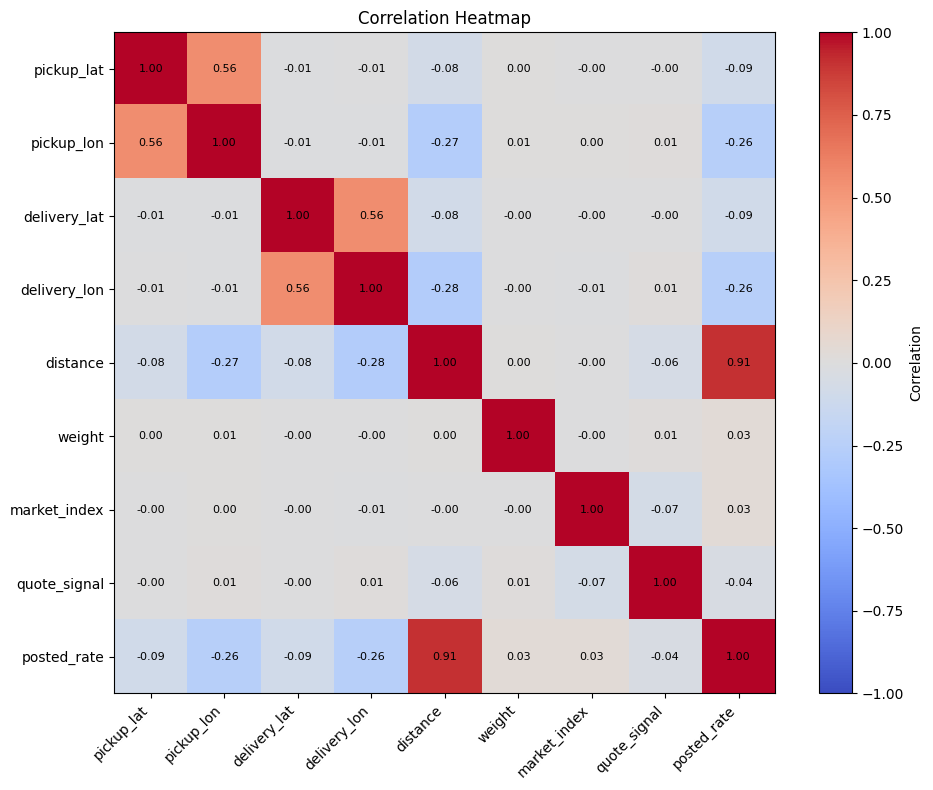

In [627]:
# Numeric columns only
corr = data.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Numbers inside the cells
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [628]:
data["quote_x_distance"] = data["quote_signal"] * data["distance"]

In [629]:
daily = data.groupby("date")["market_index"].transform("mean")
data["market_daily"] = daily
data["market_dev"] = data["market_index"] - daily

In [630]:
out_cnt = data["pickup"].value_counts()
in_cnt = data["delivery"].value_counts()

data["pickup_out"] = data["pickup"].map(out_cnt).astype(float)
data["delivery_in"] = data["delivery"].map(in_cnt).astype(float)
data["lane_balance"] = data["pickup_out"] / data["delivery_in"]

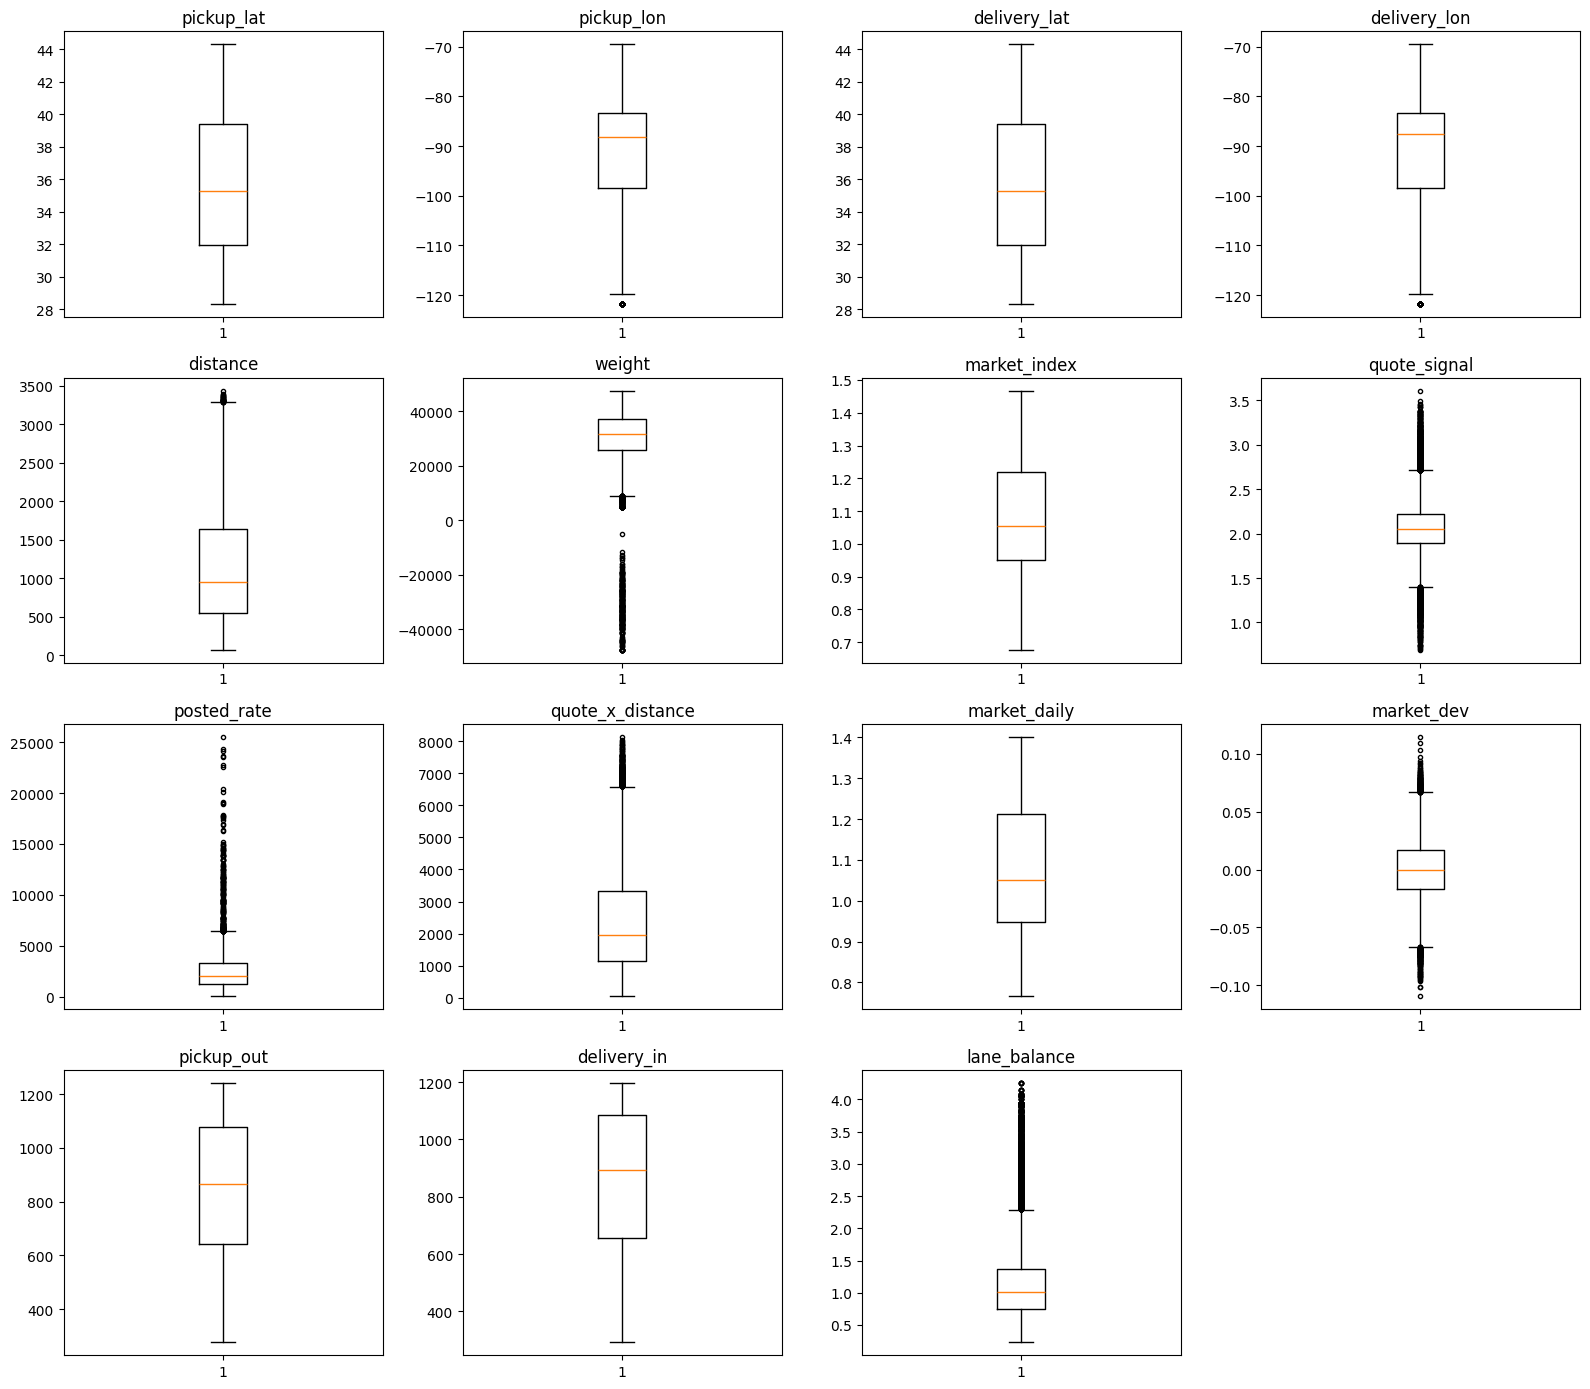

In [631]:
import numpy as np
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include="number").columns.tolist()
# убираем служебные флаги, если есть
num_cols = [c for c in num_cols if not c.endswith("_missing")]

n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.boxplot(data[col].dropna(), vert=True, flierprops={"markersize": 3})
    ax.set_title(col)

# скрыть пустые ячейки сетки
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()

In [632]:
neg = data["weight"] < 0
print(neg.sum(), neg.mean())

# сравни распределения: модуль отрицательных и обычные положительные
print(data.loc[neg, "weight"].abs().describe())
print(data.loc[~neg, "weight"].describe())

292 0.006083333333333333
count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64
count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64


In [633]:
print(data.groupby(neg)["equipment"].value_counts(normalize=True))
print(data.groupby(neg)["posted_rate"].mean())
print(data.groupby(neg)["date"].agg(["min", "max"]))

weight  equipment
False   Dry Van      0.566928
        Reefer       0.251069
        Flatbed      0.182003
True    Dry Van      0.530822
        Flatbed      0.239726
        Reefer       0.229452
Name: proportion, dtype: float64
weight
False    2373.883943
True     2389.786233
Name: posted_rate, dtype: float64
               min         max
weight                        
False   2025-01-01  2025-10-31
True    2025-01-01  2025-10-31


In [634]:
data["weight_was_negative"] = (data["weight"] < 0).astype(int)
data["weight"] = data["weight"].abs()

In [635]:
for c in ["weight", "market_index"]:
    data[c + "_missing"] = data[c].isna().astype(int)


weight_median = data["weight"].median()
data["weight"] = data["weight"].fillna(weight_median)

market_median = data["market_index"].median()
data["market_index"] = data["market_index"].fillna(
    data.groupby("date")["market_index"].transform("median")
)
data["market_index"] = data["market_index"].fillna(market_median)

In [636]:
data.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,0


In [637]:
category = ["pickup","delivery","equipment"]
data[category]

,pickup,delivery,equipment
0,Richmond,Baltimore,Dry Van
1,Richmond,Philadelphia,Reefer
2,Philadelphia,Green Bay,Dry Van
3,Hartford,Atlanta,Dry Van
4,Dallas,Nashville,Reefer
...,...,...,...
47995,Reno,Baton Rouge,Flatbed
47996,Greensboro,Memphis,Reefer
47997,Greensboro,Cincinnati,Flatbed
47998,Memphis,Reno,Flatbed


In [638]:
d = pd.to_datetime(data["date"])
data["month"] = d.dt.month
data["dayofweek"] = d.dt.dayofweek
data["day_of_year"] = d.dt.dayofyear

In [639]:
data["pickup"].drop_duplicates()

,pickup
0,Richmond
2,Philadelphia
3,Hartford
4,Dallas
5,Phoenix
...,...
214,Little Rock
237,Louisville
263,Salt Lake City
331,Las Vegas


In [640]:
data["delivery"].drop_duplicates()

,delivery
0,Baltimore
1,Philadelphia
2,Green Bay
3,Atlanta
4,Nashville
...,...
202,Little Rock
209,Detroit
247,Washington
356,Dallas


In [641]:
data["equipment"].drop_duplicates()

,equipment
0,Dry Van
1,Reefer
5,Flatbed


In [642]:
equipment_map = {"Dry Van": 1, "Reefer": 2, "Flatbed": 3}
data["equipment"] = data["equipment"].map(equipment_map)
data["equipment"]

,equipment
0,1
1,2
2,1
3,1
4,2
...,...
47995,3
47996,2
47997,3
47998,3


In [643]:
cities = pd.concat([data["pickup"], data["delivery"]]).unique()
city_type = pd.CategoricalDtype(categories=cities)

data["pickup"] = data["pickup"].astype(city_type)
data["delivery"] = data["delivery"].astype(city_type)


In [644]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   load_id               48000 non-null  object  
 1   pickup                48000 non-null  category
 2   delivery              48000 non-null  category
 3   pickup_lat            48000 non-null  float64 
 4   pickup_lon            48000 non-null  float64 
 5   delivery_lat          48000 non-null  float64 
 6   delivery_lon          48000 non-null  float64 
 7   distance              48000 non-null  float64 
 8   equipment             48000 non-null  int64   
 9   weight                48000 non-null  float64 
 10  date                  48000 non-null  object  
 11  market_index          48000 non-null  float64 
 12  quote_signal          48000 non-null  float64 
 13  posted_rate           48000 non-null  float64 
 14  quote_x_distance      48000 non-null  float64 
 15  ma

In [645]:
X = data.drop(columns=["date", "load_id", "posted_rate"], errors="ignore")
y = data["posted_rate"]

In [646]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = np.log1p(y_train)

In [647]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs': -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_va)
        scores.append(np.sqrt(mean_squared_error(y_va, preds)))

    return np.mean(scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=600)

[I 2026-09-28 15:06:22,251] A new study created in memory with name: no-name-c55d095e-ac6b-4631-ac09-515e422f7771
[I 2026-09-28 15:06:36,950] Trial 0 finished with value: 0.1615541964775362 and parameters: {'n_estimators': 200, 'learning_rate': 0.040836744221453516, 'max_depth': 6, 'subsample': 0.6005215007773848, 'colsample_bytree': 0.9177972508466379, 'reg_alpha': 2.066765244000864e-08, 'reg_lambda': 0.0017500642207623016}. Best is trial 0 with value: 0.1615541964775362.
[I 2026-09-28 15:07:26,387] Trial 1 finished with value: 0.1607789162502909 and parameters: {'n_estimators': 800, 'learning_rate': 0.022336976750334865, 'max_depth': 6, 'subsample': 0.8918656152030101, 'colsample_bytree': 0.6530892922762487, 'reg_alpha': 1.891872280503079e-05, 'reg_lambda': 0.005595038331303959}. Best is trial 1 with value: 0.1607789162502909.
[I 2026-09-28 15:07:39,391] Trial 2 finished with value: 0.15799869413212123 and parameters: {'n_estimators': 400, 'learning_rate': 0.08569826982783234, 'max_d

In [648]:
best_params = study.best_params
best_params.update({'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1})

# Исправлено: **best_params вместо **params
model = xgb.XGBRegressor(**best_params)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8985520273952049, device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.027382387935613126,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, ...)

In [649]:
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)
pred_clean = np.clip(pred, y_test.min(), y_test.max())

print(r2_score(y_test, pred_clean))

0.8694157335413226


In [650]:
val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB


In [651]:
# --- 1. equipment
val["equipment"] = val["equipment"].map(equipment_map)

# --- 2. weight
val["weight_was_negative"] = (val["weight"] < 0).astype(int)
val["weight"] = val["weight"].abs()

# --- 3. пропуски
for c in ["weight", "market_index"]:
    val[c + "_missing"] = val[c].isna().astype(int)

val["weight"] = val["weight"].fillna(weight_median)          # медиана из TRAIN, не из val

val["market_index"] = val["market_index"].fillna(
    val.groupby("date")["market_index"].transform("median")
)
val["market_index"] = val["market_index"].fillna(market_median)  # медиана из TRAIN

# --- 4. признаки из image 1
val["quote_x_distance"] = val["quote_signal"] * val["distance"]

daily = val.groupby("date")["market_index"].transform("mean")
val["market_daily"] = daily
val["market_dev"] = val["market_index"] - daily

val["pickup_out"] = val["pickup"].map(out_cnt).astype(float)      # out_cnt из TRAIN
val["delivery_in"] = val["delivery"].map(in_cnt).astype(float)    # in_cnt из TRAIN
val["lane_balance"] = val["pickup_out"] / val["delivery_in"]

# --- 5. дата
d = pd.to_datetime(val["date"])
val["month"] = d.dt.month
val["dayofweek"] = d.dt.dayofweek
val["day_of_year"] = d.dt.dayofyear

# --- 6. города
val["pickup"] = val["pickup"].astype(city_type)                   # тот же city_type, что в train
val["delivery"] = val["delivery"].astype(city_type)

# --- 7. итоговая матрица
X_val = val.drop(columns=["date", "load_id"], errors="ignore")
X_val = X_val[X_train.columns]      # тот же набор и порядок колонок, что при обучении

In [652]:
y_val_log = model.predict(X_val)
y_val = np.expm1(y_val_log)

In [654]:
out = pd.DataFrame({
    "load_id": val["load_id"].values,
    "predicted_rate": np.clip(y_val, 1, None),
})

template = pd.read_csv("validation-predictions-template.csv")
out = template[["load_id"]].merge(out, on="load_id", how="left")

assert out["predicted_rate"].notna().all()
assert len(out) == 12000 and out["load_id"].is_unique
out.to_csv("validation_predictions.csv", index=False)

In [660]:
dec = pd.read_csv("/content/december-chart-inputs.csv")   # оригинал, его не трогаем
dec_feat = dec.copy()

# --- 0. в декабре нет quote_signal и market_index: берём из последних 30 дней train
last_dates = sorted(data["date"].unique())[-30:]
recent = data[data["date"].isin(last_dates)]
quote_fixed = recent["quote_signal"].median()
market_fixed = recent["market_index"].median()

dec_feat["quote_signal"] = quote_fixed
dec_feat["market_index"] = market_fixed

# --- 1. equipment
dec_feat["equipment"] = dec_feat["equipment"].map(equipment_map)

# --- 2. weight
dec_feat["weight_was_negative"] = 0
dec_feat["weight"] = dec_feat["weight"].abs()

# --- 3. пропуски (данные полные, флаги = 0)
dec_feat["weight_missing"] = 0
dec_feat["market_index_missing"] = 0

# --- 4. признаки
dec_feat["quote_x_distance"] = dec_feat["quote_signal"] * dec_feat["distance"]

dec_feat["market_daily"] = dec_feat["market_index"]   # groupby по дате тут вырожденный
dec_feat["market_dev"] = 0.0

dec_feat["pickup_out"] = dec_feat["pickup"].map(out_cnt).astype(float)
dec_feat["delivery_in"] = dec_feat["delivery"].map(in_cnt).astype(float)
dec_feat["lane_balance"] = dec_feat["pickup_out"] / dec_feat["delivery_in"]

# --- 5. дата
d = pd.to_datetime(dec_feat["date"])
dec_feat["month"] = d.dt.month
dec_feat["dayofweek"] = d.dt.dayofweek
dec_feat["day_of_year"] = d.dt.dayofyear

# --- 6. города
dec_feat["pickup"] = dec_feat["pickup"].astype(city_type)
dec_feat["delivery"] = dec_feat["delivery"].astype(city_type)

# --- Additional step: Add geographical coordinates to dec_feat
# Get unique coordinate mappings from the training data
# --- координаты городов (словари со строковыми ключами)
pick_lat = data.assign(pickup=data["pickup"].astype(str)).drop_duplicates("pickup").set_index("pickup")
deliv_lat = data.assign(delivery=data["delivery"].astype(str)).drop_duplicates("delivery").set_index("delivery")

dec_feat["pickup_lat"]   = dec["pickup"].map(pick_lat["pickup_lat"].to_dict()).astype(float)
dec_feat["pickup_lon"]   = dec["pickup"].map(pick_lat["pickup_lon"].to_dict()).astype(float)
dec_feat["delivery_lat"] = dec["delivery"].map(deliv_lat["delivery_lat"].to_dict()).astype(float)
dec_feat["delivery_lon"] = dec["delivery"].map(deliv_lat["delivery_lon"].to_dict()).astype(float)



# --- 7. итоговая матрица
X_dec = dec_feat.drop(columns=["date", "predicted_rate"], errors="ignore")
X_dec = X_dec[X_train.columns]

# --- 8. предсказание
dec["predicted_rate"] = np.clip(np.expm1(model.predict(X_dec)), 1, None)

print(dec["predicted_rate"].describe())
dec.to_csv("december_chart_inputs.csv", index=False)

count     31.000000
mean     839.642944
std        0.032367
min      839.602905
25%      839.602905
50%      839.668274
75%      839.668274
max      839.668274
Name: predicted_rate, dtype: float64


In [662]:
!python -m pip install -r requirements.txt
!python score.py --predictions validation_predictions.csv --december-predictions december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
